In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'Arial'

In [2]:
def plot_sizes(df, title):
    
    colors = ['#f6b26b', '#56C1FF', '#93c47d']

    means = [np.mean(df.ts_num_edges), np.mean(df.linarg_nnz), np.mean(df.genotypes_nnz)]
    stds = [np.std(df.ts_num_edges), np.std(df.linarg_nnz), np.std(df.genotypes_nnz)]

    ratio_to_first = means[0] / means[1]
    ratio_to_last = means[2] / means[1]

    labels = ['Data-generating ARG \n (lower bound)', 'Inferred linear ARG', 'Sparse genotype matrix \n (upper bound)']
    x_pos = np.arange(len(labels))

    plt.figure(figsize=(9, 5))
    bars = plt.bar(
        x_pos,
        means,
        yerr=stds,
        color=colors,
        width=0.5,
        capsize=2
    )

    plt.yscale('log')
    plt.ylabel('Number of nonzero entries', fontsize=16)
    plt.xticks(ticks=x_pos, labels=labels, fontsize=16)
    plt.tick_params(axis='y', labelsize=16)
    plt.title(title, size=25)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)

    plt.text(
        x=x_pos[0],
        y=means[0] * 1.1,
        s=f"{ratio_to_first:.1f}×",
        ha='center',
        va='bottom',
        fontsize=16
    )
    
    plt.text(
    x=x_pos[2],
    y=means[2] * 1.1,
    s=f"{ratio_to_last:.1f}×",
    ha='center',
    va='bottom',
    fontsize=16
    )
    
    plt.tick_params(axis='both', labelsize=16)
    plt.show()

In [3]:
df_1e4 = pd.read_csv('data/size_comparison_results_1e4.csv')
df_1e4

,seed,genotypes_nnz,linarg_nnz,ts_num_edges,linarg_nnz_ratio
0,1,19622209,293560,146558,66.842243
1,2,20143978,295399,146759,68.192438
2,3,20146575,296097,148035,68.040456
3,4,21509435,296470,148885,72.551810
4,5,20986356,294439,147609,71.275735
...,...,...,...,...,...
95,96,19993768,294892,148555,67.800307
96,97,20433642,294958,148456,69.276446
97,98,19623380,294390,148629,66.657767
98,99,20689851,305313,147273,67.766034


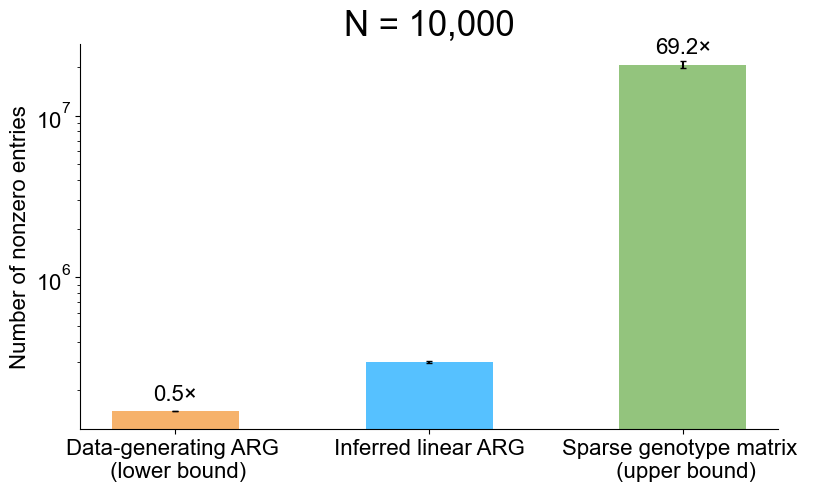

In [4]:
plot_sizes(df_1e4, 'N = 10,000')

In [5]:
df_1e5 = pd.read_csv('data/size_comparison_results_1e5.csv')
df_1e5

,seed,genotypes_nnz,linarg_nnz,ts_num_edges,n_mutations,linarg_nnz_ratio,linarg_size,ts_size
0,1,202787165,754862,581534,63048,268.641374,817910,707630
1,2,224946813,793439,582222,63775,283.508641,857214,709772
2,3,203483267,774177,582224,64023,262.838171,838200,710270
3,4,191333053,761178,583988,63856,251.364402,825034,711700
4,5,214843963,774483,583751,63946,277.403071,838429,711643
...,...,...,...,...,...,...,...,...
95,96,202763585,756016,583175,63830,268.200124,819846,710835
96,97,209185967,767019,582941,63636,272.725926,830655,710213
97,98,240922432,790360,582583,64148,304.826196,854508,710879
98,99,197822595,759984,581838,62894,260.298368,822878,707626


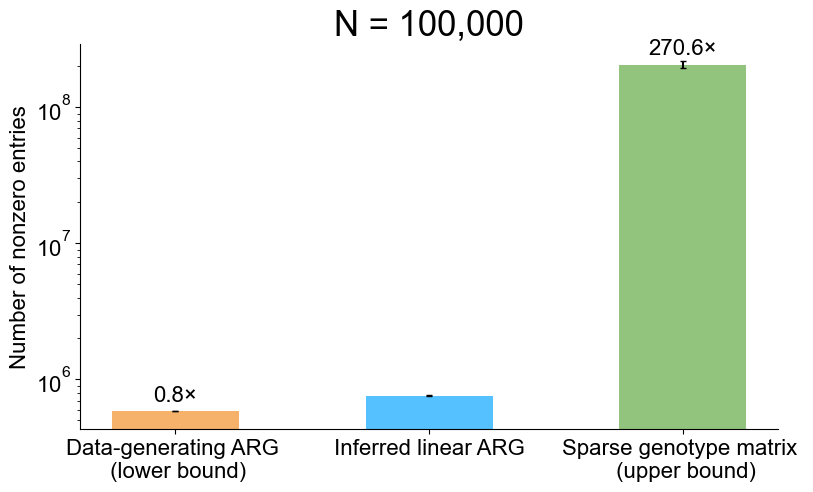

In [6]:
plot_sizes(df_1e5, 'N = 100,000')